# Boosted Frank-Wolfe algorithm

## Problem

We want to solve
$$\min\limits_{X\in\mathbb{R}^{n}} \frac{1}{2}\|Ax-b\|^2 + \iota_{\mathcal{C}}(x)$$
where $A\in\mathbb{R}^{m\times n}$ and
$$\mathcal{C} = \{x:\|x\|_1\leq \rho\}$$
The gradient of the objective function is given by
$$\nabla f(x) = A^*(Ax-b)$$
and the linear minimization oracle is just finding the largest entry of the gradient in magnitude.

## Algorithm

The Boosted Frank-Wolfe algorithm improves upon the standard Frank-Wolfe method by better aligning the descent direction with the negative gradient. The main steps of the algorithm are:

1. Initialize $x_0 \in \mathcal{C}$
2. For $t = 0, 1, \ldots, T-1$:
   * Compute the gradient $\nabla f(x_t)$
   * Perform gradient pursuit:
      - Initialize $d_0 = 0$, $\Lambda_t = 0$
      - For $k = 0, 1, \ldots, K-1$:
        * Compute residual $r_k = -\nabla f(x_t) - d_k$
        * Find $v_k = \arg\max_{v \in \mathcal{C}} \langle r_k, v \rangle$
        * Choose $u_k = \arg\max_{u \in \{v_k - x_t, -d_k/\|d_k\|\}} \langle r_k, u \rangle$
        * Compute $\lambda_k = \frac{\langle r_k, u_k \rangle}{\|u_k\|^2}$
        * Update $d_{k+1} = d_k + \lambda_k u_k$
        * Update $\Lambda_t$ accordingly
        * If alignment improvement is insufficient, break
   * Compute descent direction $g_t = d_K / \Lambda_t$
   * Choose step size $\gamma_t$ (e.g., short step or line search)
   * Update $x_{t+1} = x_t + \gamma_t g_t$

## Convergence

The Boosted Frank-Wolfe algorithm achieves the following convergence rates:

1. For the general case (Theorem 3.3):
   $$f(x_t) - \min_{\mathcal{C}} f \leq \frac{4LD^2}{t + 2}$$
   where $L$ is the smoothness constant of $f$ and $D$ is the diameter of $\mathcal{C}$.

2. For the practical case (Theorem 3.4), assuming sufficient improvement in each iteration:
   $$f(x_t) - \min_{\mathcal{C}} f \leq \frac{LD^2}{2} \exp\left(-\delta^2 \frac{\mu}{L} \omega t^p\right)$$
   where $\mu$ is the gradient dominance constant, $\delta$ is the alignment improvement tolerance, $\omega > 0$, and $p \in (0, 1]$.

In [5]:
import sys
import os

# Get the current working directory
current_dir = os.getcwd()

# Add the parent directory to the system path
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

# Now you can import from frank_wolfe
from frank_wolfe import *
from frank_wolfe.core.utils import *

import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Define your objective function
class BoostingObjective(ObjectiveFunction):
    def __init__(self, A, b, lipschitz,):
        self.A = A
        self.b = b
        self.lipschitz = lipschitz
    
    def evaluate(self, x):
        # Implement your objective function here
        return 0.5 * (np.linalg.norm((self.A@x - self.b).flatten()) ** 2)
    
    def gradient(self, x):
        # Implement the gradient of your objective function here
        return self.A.T@(self.A@x - self.b)

In [7]:
n = int(1e2)
m = int(1e1)
A = (2 * np.random.rand(m, n)) - 1
A = 0.1 * A
At = A.T
lipschitz = np.linalg.norm(A.T@A, ord=2)
X_ground_truth = np.random.rand(n)
X_small = X_ground_truth < 0.2
X_ground_truth[X_small] = 0
b = A @ X_ground_truth
X0 = np.random.rand(n)
X0 = (0.7 * X0 / (np.linalg.norm(X0, ord=1))) * np.linalg.norm(X_ground_truth, ord=1)

Boosted Frank-Wolfe Progress: 100%|██████████| 10/10 [00:00<00:00, 1611.89it/s]


The two nnmp procedures used the same number of oracles:
og_num_orac=5
num_oracles=5
The two nnmp procedures produced the same direction:
3.2464407861887556e-15
The two nnmp procedures used the same number of oracles:
og_num_orac=5
num_oracles=5
The two nnmp procedures produced the same direction:
5.154580408581191e-15
The two nnmp procedures used the same number of oracles:
og_num_orac=5
num_oracles=5
The two nnmp procedures produced the same direction:
5.948237287945521e-15
The two nnmp procedures used the same number of oracles:
og_num_orac=5
num_oracles=5
The two nnmp procedures produced the same direction:
7.955683190311303e-15
The two nnmp procedures used the same number of oracles:
og_num_orac=5
num_oracles=5
The two nnmp procedures produced the same direction:
1.8656981228813396e-15
The two nnmp procedures used the same number of oracles:
og_num_orac=5
num_oracles=5
The two nnmp procedures produced the same direction:
4.809575819351605e-15
The two nnmp procedures used the same 

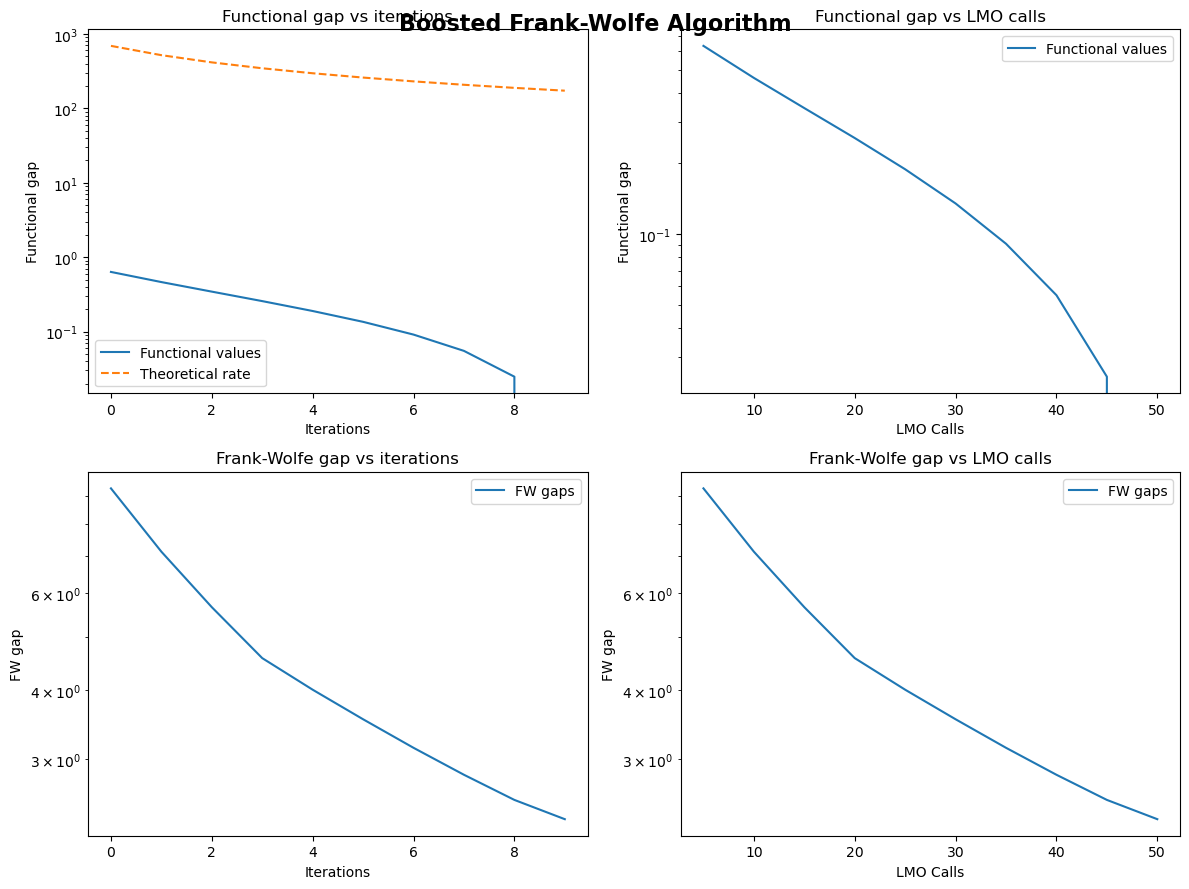

Final objective value: 0.14465632407494108


In [8]:
# Create the objective function and LMO
obj_fn = BoostingObjective(A, b, lipschitz)
radius = 1 * np.linalg.norm(X_ground_truth, ord=1)
constraint_set = 'l1_ball'
lmo_fn = create_lmo(radius, constraint_set)

# Initialize the algorithm
x0 = np.random.randn(n)
x0 = 0.8 * x0 / np.linalg.norm(x0, ord=1) * radius  # Project onto the L1 ball

# Create and run the Boosted Frank-Wolfe algorithm
Boosted = BoostedFrankWolfe(obj_fn, lmo_fn, 2*radius)
Boosted.run(x0, n_steps=10, K=5, delta=1e-3, step_size_strategy='Short')

# Plot the results
Boosted.plot_convergence()

# Print the final objective value
print(f"Final objective value: {obj_fn.evaluate(Boosted.x)}")